In [1]:
import sys
sys.path.insert(0, '/workspaces/CUBES/beizaee')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Import analysis functions
from analysis.shared import load_run_csv
from analysis.shared.constants import (
    ROOM_MAPPING,
    FLOOR_AREAS,
    BEIZAEE_REFERENCE,
    CONTROL_COLORS
)
from analysis.thermostat import (
    compare_room_temperatures,
    compute_temperature_deltas,
    compare_gas_consumption,
    boiler_efficiency,
    daily_summary,
    calculate_kwh_per_day
)
from analysis.thermostat.plotting import (
    plot_boiler_config_comparison,
    plot_absolute_temperatures_with_beizaee_period,
    plot_gas_consumption_by_config,
    plot_daily_gas_consumption
)

print("✓ Imports successful")

✓ Imports successful


In [11]:
from pathlib import Path

def load_run(path):
    p=Path(path)
    if not p.exists(): raise FileNotFoundError(f"Missing: {p}")
    df=load_run_csv(str(p))
    print(f"Loaded {p.parent.name}: {len(df)} rows, {len(df.columns)} cols, {df.index[0]} → {df.index[-1]}")
    return df

base=Path("/workspaces/CUBES/beizaee/experiments/thermostat/runs_evaluation/lynch")
df_conv=load_run(base/"conventional_control__part_2__eff_quadratic"/"eplusout.csv")
df_zonal=load_run(base/"zonal_control__part_2__eff_quadratic"/"eplusout.csv")
df_occ=load_run(base/"occupancy_control__part_2__eff_quadratic"/"eplusout.csv")

# Create results dictionary for plot_boiler_config_comparison
results = {
    "conventional_control__part_2__eff_quadratic": df_conv,
    "zonal_control__part_2__eff_quadratic": df_zonal,
    "occupancy_control__part_2__eff_quadratic": df_occ,
}



Loaded conventional_control__part_2__eff_quadratic: 5863 rows, 364 cols, 2013-03-03 00:10:00 → 2013-04-21 23:50:00
Loaded zonal_control__part_2__eff_quadratic: 5863 rows, 364 cols, 2013-03-03 00:10:00 → 2013-04-21 23:50:00
Loaded occupancy_control__part_2__eff_quadratic: 5863 rows, 364 cols, 2013-03-03 00:10:00 → 2013-04-21 23:50:00


,Conventional,Zonal,Occupancy
Part-load: 2 Eff. Curve: quadratic,56.43,52.08,50.44


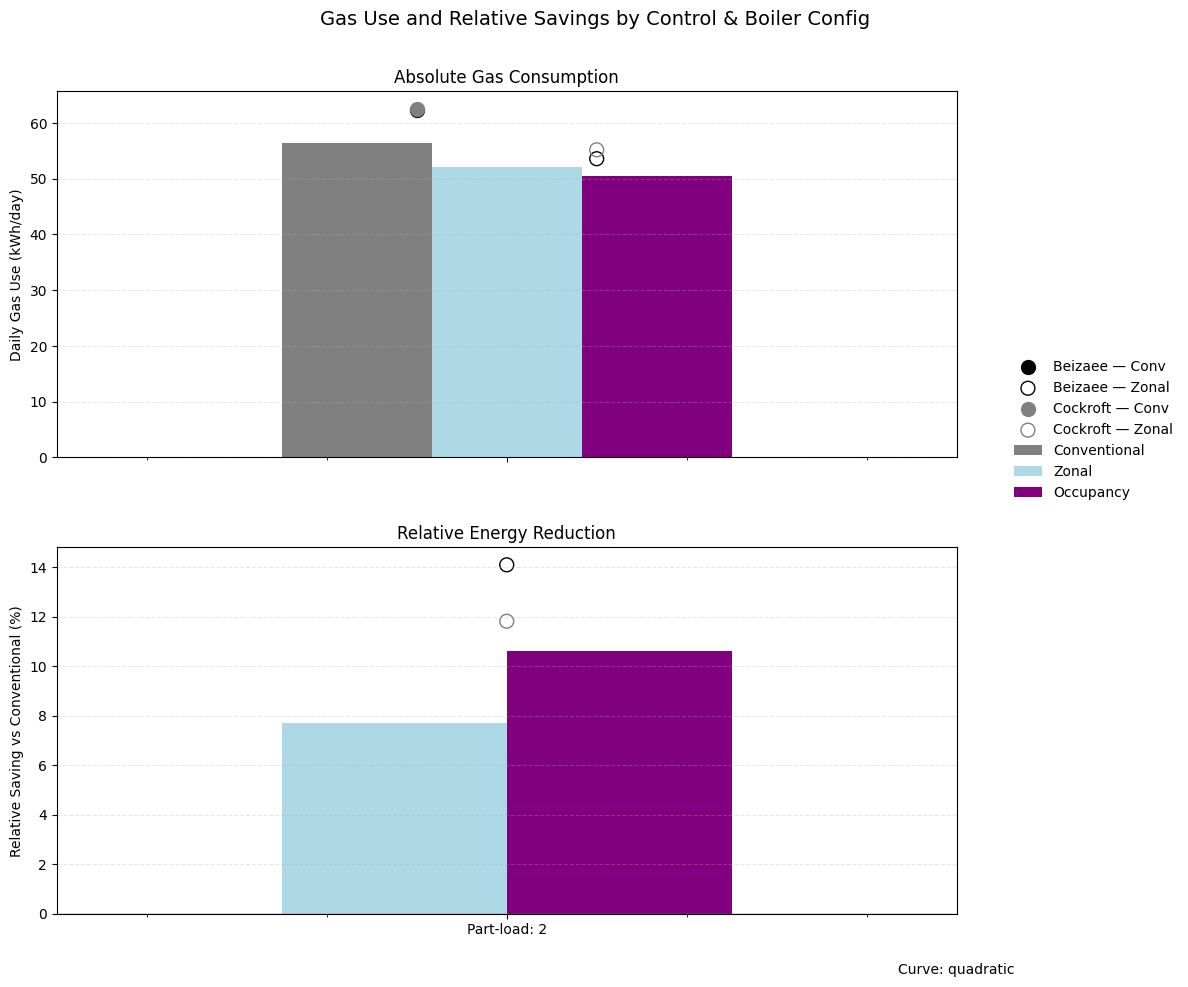

In [12]:
plot_gas_consumption_by_config(
    results,
    controls=["conventional_control", "zonal_control", "occupancy_control"],
    show_references=True)


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

def extract_occupied_stats(df, room_mapping):
    """Return dict: {room: (mean, min, max)} for occupied-only temperatures."""
    out = {}
    for zone, room in room_mapping.items():
        temp_cols = [c for c in df.columns if zone in c and "Zone Air Temperature" in c]
        occ_cols  = [c for c in df.columns if zone in c and "People Occupant Count" in c]

        if not temp_cols or not occ_cols:
            continue

        temp = df[temp_cols[0]]
        occ  = df[occ_cols[0]]

        occ_temp = temp[occ > 0]
        if len(occ_temp) == 0:
            continue

        out[room] = {
            "mean": occ_temp.mean(),
            "min":  occ_temp.min(),
            "max":  occ_temp.max()
        }
    return pd.DataFrame(out).T  # rows = rooms


def plot_room_temperature_bars(df_conv, df_zonal, df_occ, room_mapping):
    """Grouped bar chart comparing (mean ± range) for occupied-only temps."""
    conv = extract_occupied_stats(df_conv, room_mapping)
    zon  = extract_occupied_stats(df_zonal, room_mapping)
    occ  = extract_occupied_stats(df_occ, room_mapping)

    # Ensure consistent room ordering
    rooms = sorted(list(set(conv.index) | set(zon.index) | set(occ.index)))

    # Build table with aligned rows
    stats = {
        "Conventional": conv.reindex(rooms),
        "Zonal":        zon.reindex(rooms),
        "Occupancy":    occ.reindex(rooms),
    }

    # Plot
    fig, ax = plt.subplots(figsize=(14,6))

    x = range(len(rooms))
    width = 0.25

    for i, (label, df_stats) in enumerate(stats.items()):
        means = df_stats["mean"]
        mins  = df_stats["min"]
        maxs  = df_stats["max"]

        # Error bars = min/max deviation
        yerr = [means - mins, maxs - means]

        ax.bar(
            [xi + (i - 1)*width for xi in x],
            means,
            width=width,
            label=label,
            yerr=yerr,
            capsize=4
        )

    ax.set_xticks(x)
    ax.set_xticklabels(rooms, rotation=45, ha="right")
    ax.set_ylabel("Occupied Temperature [°C]")
    ax.set_title("Occupied Temperature Comparison by Room and Control Type")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()


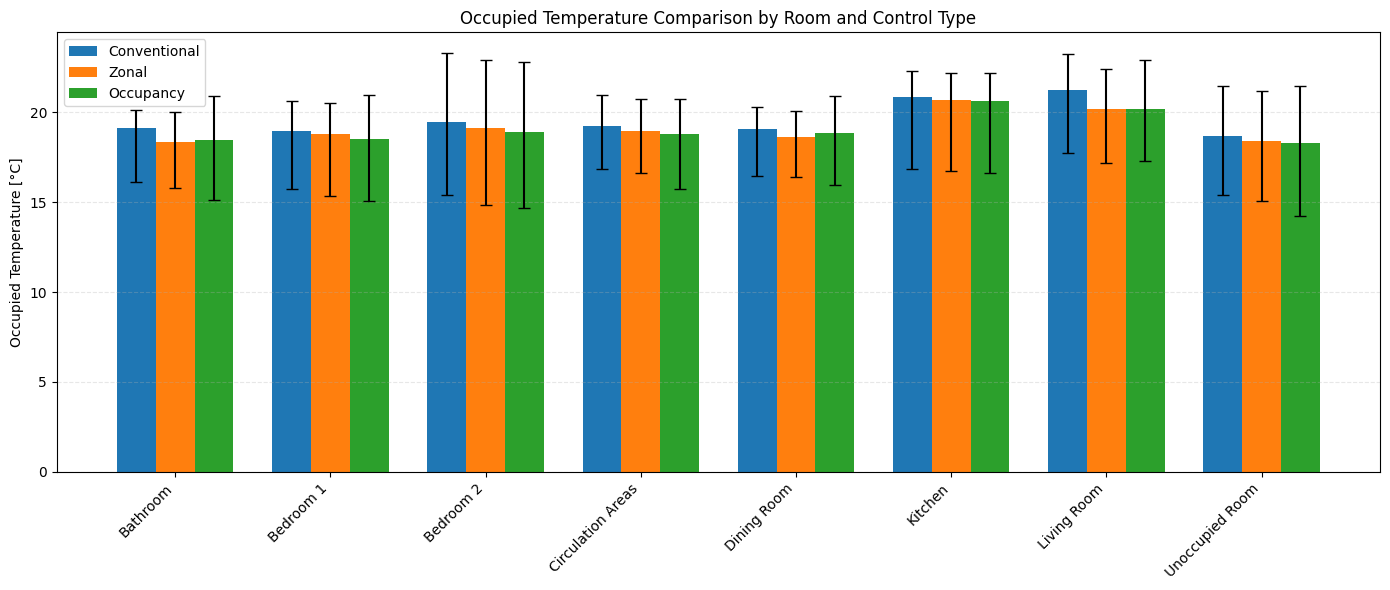

In [14]:
plot_room_temperature_bars(df_conv, df_zonal, df_occ, ROOM_MAPPING)


In [15]:
def build_room_data(df, room_mapping):
    """Return dict: room -> {Temperature, Occupancy}"""
    room_data = {}

    temp_cols = [c for c in df.columns if "zone air temperature" in c.lower()]
    occ_cols  = [c for c in df.columns if "people occupant count" in c.lower()]

    # Lowercase mapping for stable matching
    reverse_map = {zone.lower(): name for zone, name in room_mapping.items()}

    for col in temp_cols:
        raw_zone = col.split(":")[0].strip().lower()
        if raw_zone not in reverse_map:
            continue

        room = reverse_map[raw_zone]
        room_data.setdefault(room, {})["Temperature"] = df[col]

    for col in occ_cols:
        raw_zone = col.split(":")[0].strip().lower()
        if raw_zone not in reverse_map:
            continue

        room = reverse_map[raw_zone]
        room_data.setdefault(room, {})["Occupancy"] = df[col]

    return room_data


def filter_room_data(room_data, ignore_sleep_hours=False):
    """
    Apply occupancy filter to room_data and optionally remove 00:00–06:00.

    Returns a new dict with:
        room -> Series of occupied temperatures only
    """
    filtered = {}

    for room, data in room_data.items():
        temp = data.get("Temperature")
        occ  = data.get("Occupancy")

        if temp is None or occ is None:
            continue  # skip rooms with missing data

        # Occupied timesteps
        mask = occ > 0

        # Remove sleep hours if requested
        if ignore_sleep_hours:
            hours = temp.index.hour
            mask &= (hours >= 6)  # keep only 06:00 → 23:59

        filtered[room] = temp[mask]

    return filtered


In [25]:
def build_room_data(df, room_mapping):
    """
    Constructs a nested dict of room → {Temperature, Occupancy}
    using ROOM_MAPPING to harmonise names.

    Returns:
        room_data[room_name]["Temperature"] = Series
        room_data[room_name]["Occupancy"]   = Series
    """

    room_data = {}

    temp_cols = [c for c in df.columns if "zone air temperature" in c.lower()]
    occ_cols  = [c for c in df.columns if "people occupant count" in c.lower()]

    reverse_map = {zone.lower(): name for zone, name in room_mapping.items()}

    # assign temperature columns
    for col in temp_cols:
        raw_zone = col.split(":")[0].strip().lower()
        if raw_zone not in reverse_map:
            continue

        room = reverse_map[raw_zone]
        room_data.setdefault(room, {"Temperature": None, "Occupancy": None})
        room_data[room]["Temperature"] = df[col]

    # assign occupancy columns
    for col in occ_cols:
        raw_zone = col.split(":")[0].strip().lower()
        if raw_zone not in reverse_map:
            continue

        room = reverse_map[raw_zone]
        room_data.setdefault(room, {"Temperature": None, "Occupancy": None})
        room_data[room]["Occupancy"] = df[col]

    return room_data


def filter_room_data(room_data, ignore_sleep_hours=False):
    """
    Returns a room_data-style dict but with Temperature filtered to:
        - occupied timesteps only (Occupancy > 0)
        - optionally excluding 00:00–06:00 (ignore_sleep_hours=True)
    """

    filtered = {}

    for room, data in room_data.items():
        temp = data.get("Temperature")
        occ  = data.get("Occupancy")

        if temp is None or occ is None:
            continue

        mask = occ > 0

        if ignore_sleep_hours:
            hours = temp.index.hour
            mask &= (hours >= 6)

        filtered_temp = temp[mask]

        filtered[room] = {
            "Temperature": filtered_temp,
            "Occupancy": occ
        }

    return filtered

import numpy as np
import matplotlib.pyplot as plt

def plot_cdf_temperatures(room_data_dict, controls=("Conventional","Zonal","Occupancy")):
    """
    room_data_dict = {
        "Conventional": filtered_room_data_conv,
        "Zonal":        filtered_room_data_zonal,
        "Occupancy":    filtered_room_data_occ
    }
    """
    rooms = list(next(iter(room_data_dict.values())).keys())
    n = len(rooms)

    fig, axes = plt.subplots(nrows=n, figsize=(10, 3*n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, room in zip(axes, rooms):
        for ctrl in controls:
            rd = room_data_dict.get(ctrl)
            if rd is None or room not in rd:
                continue

            temp = rd[room]["Temperature"]
            occ_temp = temp.dropna()
            if occ_temp.empty:
                continue

            # Sort + CDF
            sv = np.sort(occ_temp)
            cdf = np.linspace(0, 1, len(sv))

            # Plot and capture colour
            line, = ax.plot(sv, cdf, label=ctrl)
            color = line.get_color()

            # Median
            med = np.median(occ_temp)

            # Marker
            ax.scatter([med], [0.5], s=40, marker="o", color=color)

            # vline in same colour
            ax.axvline(med, linestyle="--", alpha=0.6, color=color)

            # Label only the value
            ax.text(
                med, 0.5,
                f"{med:.1f}°C",
                ha="left",
                va="bottom",
                fontsize=8,
                color=color
            )

        ax.set_title(room)
        ax.set_ylabel("CDF")
        ax.grid(True, linestyle="--", alpha=0.4)

    axes[-1].set_xlabel("Occupied Temperature [°C]")
    plt.tight_layout()
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


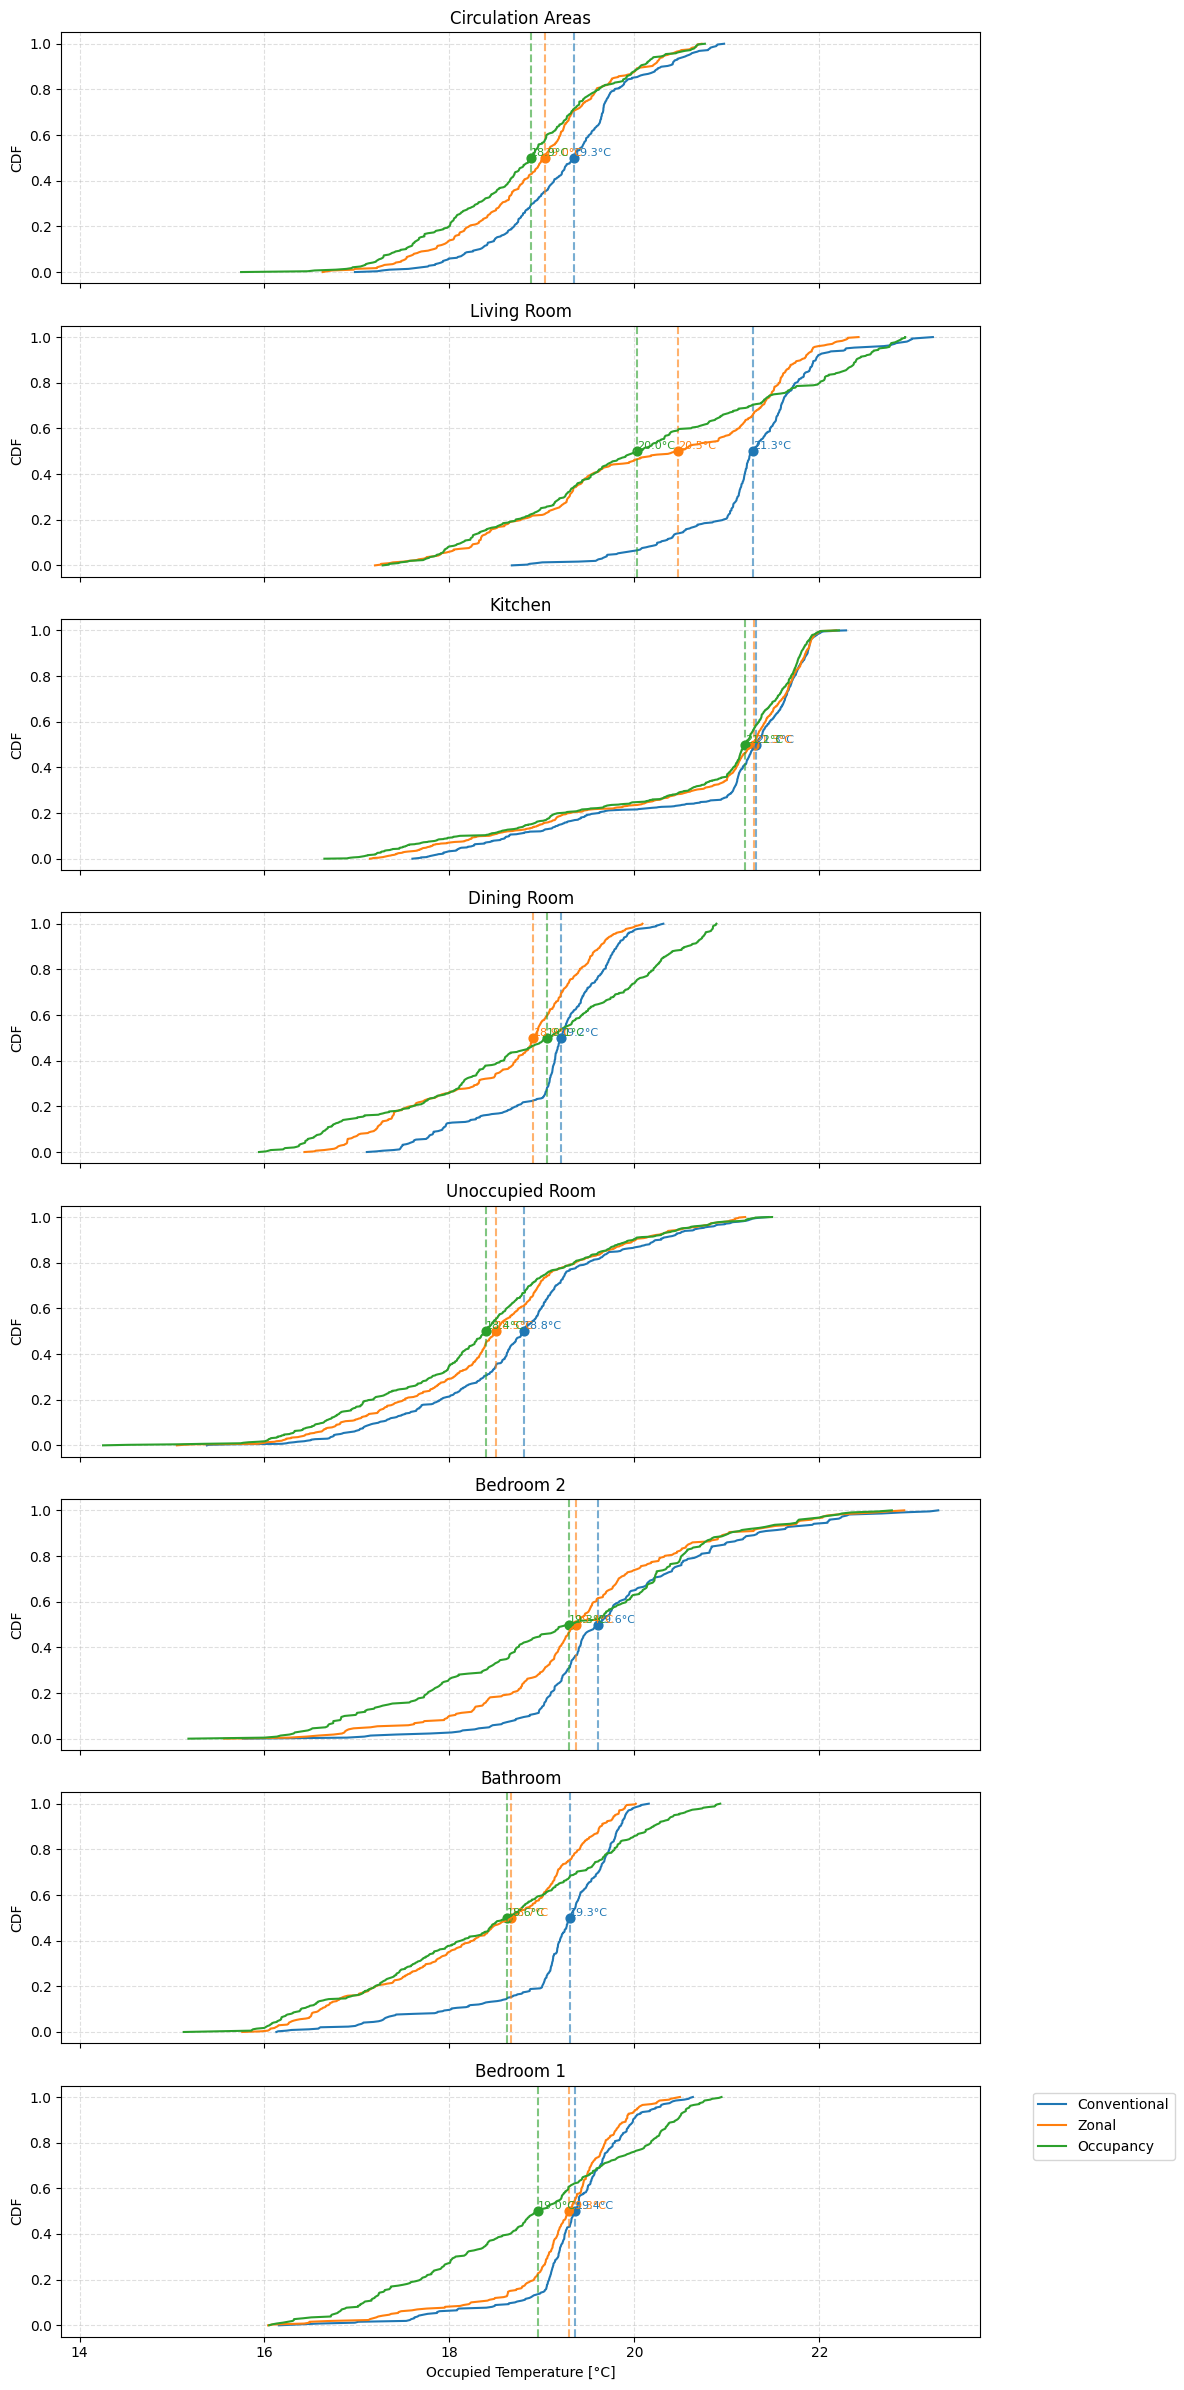

In [26]:
room_conv = build_room_data(df_conv, ROOM_MAPPING)
room_zonal = build_room_data(df_zonal, ROOM_MAPPING)
room_occ = build_room_data(df_occ, ROOM_MAPPING)

filtered_conv = filter_room_data(room_conv, ignore_sleep_hours=True)
filtered_zonal = filter_room_data(room_zonal, ignore_sleep_hours=True)
filtered_occ = filter_room_data(room_occ, ignore_sleep_hours=True)

plot_cdf_temperatures(
    {
        "Conventional": filtered_conv,
        "Zonal":        filtered_zonal,
        "Occupancy":    filtered_occ
    }
)


In [22]:
import matplotlib.pyplot as plt
import numpy as np

def plot_violin_temperatures(room_data_dict, controls=("Conventional","Zonal","Occupancy")):
    """
    Creates a grouped violin plot showing the occupied temperature distribution
    for each room and each control type.

    room_data_dict = {
        "Conventional": filtered_room_data_conv,
        "Zonal":        filtered_room_data_zonal,
        "Occupancy":    filtered_room_data_occ
    }
    """

    rooms = list(next(iter(room_data_dict.values())).keys())
    n_rooms = len(rooms)
    n_ctrl = len(controls)

    fig, ax = plt.subplots(figsize=(14, 6))

    # X positions for groups
    x = np.arange(n_rooms)

    # spacing between violins inside each room-group
    width = 0.25
    offsets = np.linspace(-width, width, n_ctrl)

    for idx_ctrl, ctrl in enumerate(controls):
        rd = room_data_dict.get(ctrl)
        if rd is None:
            continue

        distro = []
        for room in rooms:
            if room not in rd:
                distro.append([])
                continue
            vals = rd[room]["Temperature"].dropna()
            distro.append(vals.values)

        pos = x + offsets[idx_ctrl]

        parts = ax.violinplot(distro, positions=pos, widths=0.22,
                              showextrema=True, showmeans=True)

        # Style improvement
        for pc in parts["bodies"]:
            pc.set_alpha(0.5)

        ax.scatter(pos, [np.mean(d) if len(d)>0 else np.nan for d in distro],
                   label=ctrl, s=25)

    ax.set_xticks(x)
    ax.set_xticklabels(rooms, rotation=45, ha="right")
    ax.set_ylabel("Occupied Temperature [°C]")
    ax.set_title("Occupied Temperature Distribution by Room (Violin Plot)")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()



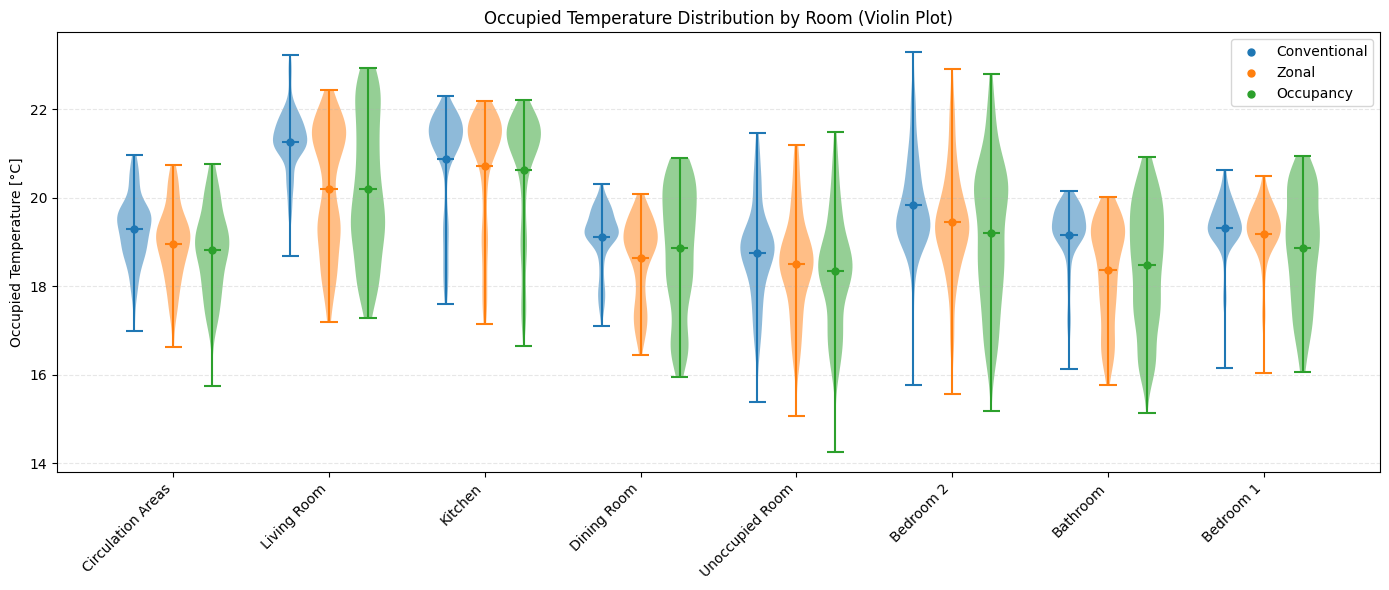

In [21]:
room_conv = build_room_data(df_conv, ROOM_MAPPING)
room_zonal = build_room_data(df_zonal, ROOM_MAPPING)
room_occ  = build_room_data(df_occ,  ROOM_MAPPING)

filtered_conv = filter_room_data(room_conv, ignore_sleep_hours=True)
filtered_zonal = filter_room_data(room_zonal, ignore_sleep_hours=True)
filtered_occ  = filter_room_data(room_occ,  ignore_sleep_hours=True)

plot_violin_temperatures(
    {
        "Conventional": filtered_conv,
        "Zonal":        filtered_zonal,
        "Occupancy":    filtered_occ
    }
)


In [ ]:

# Plot temperature differences (Conventional - Smart Controls)
# This shows how much warmer/cooler conventional control is compared to zonal/occupancy
fig, ax = plot_boiler_config_comparison(
    results_dict=results,
    config_tag="part_2__eff_quadratic",  # Filter to this boiler config
    room_mapping=ROOM_MAPPING,
    beizaee_cockroft_deltas=None,  # Uses default BEIZAEE_COCKROFT_DELTAS
    controls=["conventional_control", "zonal_control" ,"occupancy_control"],
    run_label="Evaluation Period"
)
plt.show()



In [ ]:
plot_gas_consumption_by_config(
    results,
    controls=["conventional_control", "zonal_control", "occupancy_control"],
    show_references=True)


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def get_room_timeseries_dict(df, room_mapping):
    """Return {BeizaeeRoom: DataFrame(Temperature, Occupancy)}."""
    room_dict = {}
    for zone, beizaee_name in room_mapping.items():
        temp_cols = [c for c in df.columns if "zone air temperature" in c.lower() and zone in c]
        occ_cols = [c for c in df.columns if "occupant count" in c.lower() and zone in c]

        if not temp_cols:
            continue

        room_df = pd.DataFrame(index=df.index)
        room_df["Temperature"] = df[temp_cols].mean(axis=1)

        if occ_cols:
            room_df["Occupancy"] = df[occ_cols].mean(axis=1)
        else:
            room_df["Occupancy"] = 0

        room_dict[beizaee_name] = room_df

    return room_dict


def plot_avg_occupied_unoccupied_temps(df, room_mapping):
    """Creates a bar chart of average temps per room."""
    room_data = get_room_timeseries_dict(df, room_mapping)

    rows = []
    for room, rdf in room_data.items():
        temp = rdf["Temperature"]
        occ = rdf["Occupancy"] > 0

        rows.append({
            "Room": room,
            "AvgTemp": temp.mean(),
            "AvgOccTemp": temp[occ].mean() if occ.any() else None,
            "AvgUnoccTemp": temp[~occ].mean() if (~occ).any() else None,
            "MinTemp": temp.min(),
            "MaxTemp": temp.max(),
        })

    stats = pd.DataFrame(rows).set_index("Room").sort_index()

    fig, ax = plt.subplots(figsize=(12, 6))

    x = range(len(stats))

    ax.bar([i - 0.2 for i in x], stats["AvgOccTemp"], width=0.2, color="C1", label="Occupied")
    ax.bar(x, stats["AvgTemp"], width=0.2, color="C0", label="Overall")
    ax.bar([i + 0.2 for i in x], stats["AvgUnoccTemp"], width=0.2, color="C2", label="Unoccupied")

    # Add min–max whiskers
    ax.vlines(x, stats["MinTemp"], stats["MaxTemp"], color="grey", linewidth=1)

    ax.set_xticks(list(x))
    ax.set_xticklabels(stats.index, rotation=45, ha="right")

    ax.set_ylabel("Temperature [°C]")
    ax.set_title("Average Temperatures (Occupied vs Unoccupied)")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend()

    fig.tight_layout()
    return stats, fig, ax


In [ ]:
stats, fig, ax = plot_avg_occupied_unoccupied_temps(df_conv, ROOM_MAPPING)
plt.show()

print(stats.round(2))


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def get_room_timeseries_dict(df, room_mapping):
    room_dict = {}
    for zone, beizaee_name in room_mapping.items():
        temp_cols=[c for c in df.columns if "zone air temperature" in c.lower() and zone in c]
        occ_cols=[c for c in df.columns if "occupant count" in c.lower() and zone in c]

        if not temp_cols:
            continue

        room_df=pd.DataFrame(index=df.index)
        room_df["Temperature"]=df[temp_cols].mean(axis=1)
        room_df["Occupancy"]=df[occ_cols[0]] if occ_cols else 0
        room_dict[beizaee_name]=room_df
    return room_dict


def plot_occupied_temperature_boxplot(df, room_mapping):
    room_data=get_room_timeseries_dict(df, room_mapping)

    rows=[]
    for room, rdf in room_data.items():
        occ_temps=rdf["Temperature"][rdf["Occupancy"]>0]
        if len(occ_temps)==0:
            continue
        for temp in occ_temps:
            rows.append({"Room": room, "Temperature": temp})

    long_df=pd.DataFrame(rows)

    fig, ax=plt.subplots(figsize=(12,6))
    long_df.boxplot(by="Room", column="Temperature", ax=ax, grid=False, patch_artist=True)

    ax.set_title("Occupied Temperature Distribution by Room")
    ax.set_ylabel("Temperature [°C]")
    plt.suptitle("")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    return long_df, fig, ax


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_occupied_temperature_violin(room_data, room_mapping):
    """
    Create a violin plot of occupied temperature distribution for each room
    based on ROOM_MAPPING categories.
    """
    # Build long-form dataframe
    records = []
    for zone, data in room_data.items():
        room = room_mapping.get(zone, zone)
        temps = data["Temperature"]
        occ = data["Occupancy"]

        # Only occupied times
        occupied_temps = temps[occ > 0]

        for t in occupied_temps:
            records.append({"Room": room, "Temperature": t})

    df = pd.DataFrame(records)

    # Sort rooms by average occupied temperature (optional)
    df["Room"] = pd.Categorical(df["Room"],
                                categories=sorted(df["Room"].unique(),
                                                  key=lambda r: df[df["Room"] == r]["Temperature"].mean()),
                                ordered=True)

    # Plot
    plt.figure(figsize=(14, 6))
    sns.violinplot(data=df, x="Room", y="Temperature", inner="quartile")

    plt.title("Occupied Temperature Distribution by Room")
    plt.ylabel("Temperature [°C]")
    plt.xlabel("Room")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return df


In [ ]:
# Create and display the violin plot
room_data=get_room_timeseries_dict(df_conv, ROOM_MAPPING)
df_violin = plot_occupied_temperature_violin(room_data, ROOM_MAPPING)
